### Clean Met TRAM - from Synoptic Data

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import dates
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

# import rioxarray
# import rasterio 
import cfgrib
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/tram'

## Open TRAM Station Observations

In [3]:
# filename = '/hdd/snow_hydrology/met_station/tram/JTMA2_MountRoberts_Tram_Synoptic_everything_utc_until_2025-10-08.csv'
filename = '/hdd/snow_hydrology/met_station/tram/JTMA2.2026-03-20.csv' # this one is everything downloaded until 20 March 2026 
df_met = pd.read_csv(filename, sep = ",", low_memory=False, skiprows=10)
df_met['datetime'] = pd.to_datetime(df_met['Date_Time'], utc=True)
# set datetime as the index
df_met = df_met.iloc[1:].copy() # skipping that first row since it's the units row
df_met.set_index('datetime', inplace=True)
df_met.head()

,Station_ID,Date_Time,air_temp_set_1,relative_humidity_set_1,wind_speed_set_1,wind_direction_set_1,wind_gust_set_1,snow_depth_set_1,solar_radiation_set_1,precip_accum_set_1,volt_set_1,snow_interval_set_1,wind_chill_set_1d,wind_cardinal_direction_set_1d,heat_index_set_1d,dew_point_temperature_set_1d
datetime,,,,,,,,,,,,,,,,
2014-08-27 03:00:00+00:00,JTMA2,2014-08-27T03:00:00Z,8.92,100.0,NaN,NaN,NaN,NaN,NaN,1.524,NaN,NaN,NaN,NaN,NaN,8.92
2014-08-27 03:15:00+00:00,JTMA2,2014-08-27T03:15:00Z,8.9,100.0,NaN,NaN,NaN,NaN,NaN,0.508,NaN,NaN,NaN,NaN,NaN,8.9
2014-08-27 03:30:00+00:00,JTMA2,2014-08-27T03:30:00Z,8.83,100.0,NaN,NaN,NaN,NaN,NaN,0.508,NaN,NaN,NaN,NaN,NaN,8.83
2014-08-27 03:45:00+00:00,JTMA2,2014-08-27T03:45:00Z,8.8,100.0,NaN,NaN,NaN,NaN,NaN,0.508,NaN,NaN,NaN,NaN,NaN,8.8
2014-08-27 04:00:00+00:00,JTMA2,2014-08-27T04:00:00Z,8.8,100.0,NaN,NaN,NaN,NaN,NaN,0.762,NaN,NaN,NaN,NaN,NaN,8.8


In [4]:
# Keep only desired variables and rename them
df_met = df_met[
    [
        'air_temp_set_1',
        'relative_humidity_set_1',
        # 'wind_speed_set_1', # wind looks really bad and is only there for a few years before 2020
        # 'wind_direction_set_1',
        'snow_depth_set_1',
        'solar_radiation_set_1',
        'precip_accum_set_1'
    ]
].copy()

df_met = df_met.rename(columns={
    'air_temp_set_1': 'temp',
    'relative_humidity_set_1': 'rh',
    # 'wind_speed_set_1': 'wind', 
    # 'wind_direction_set_1': 'wind_dir',
    'snow_depth_set_1': 'hs',
    'solar_radiation_set_1': 'solar_rad',
    'precip_accum_set_1': 'precip_accum'
})

# -----------------------------------------------------------------------------
# Convert all variables to numeric
# (forces strings/object columns into floats, invalid values -> NaN)
# -----------------------------------------------------------------------------

for col in df_met.columns:
    df_met[col] = pd.to_numeric(df_met[col], errors='coerce')

# -----------------------------------------------------------------------------
# Fix datetime index
# -----------------------------------------------------------------------------

df_met.index = pd.to_datetime(df_met.index, utc=True)
df_met = df_met.sort_index()

# Remove timezone for xarray compatibility
df_met.index = df_met.index.tz_convert(None)

# -----------------------------------------------------------------------------
# Convert to xarray
# -----------------------------------------------------------------------------

ds_met = xr.Dataset.from_dataframe(df_met)

# Rename index dimension to time
ds_met = ds_met.rename({'datetime': 'time'})

# -----------------------------------------------------------------------------
# Select desired period
# -----------------------------------------------------------------------------

ds_met = ds_met.sel(
    time=slice(
        "2014-10-01T05:00:00",
        "2025-09-30T05:00:00"
    )
)

# -----------------------------------------------------------------------------
# Check result
# -----------------------------------------------------------------------------

ds_met

<xarray.Dataset> Size: 4MB
Dimensions:       (time: 92896)
Coordinates:
  * time          (time) datetime64[ns] 743kB 2014-10-01T05:00:00 ... 2025-09...
Data variables:
    temp          (time) float64 743kB 1.62 1.57 1.49 1.41 ... 6.68 4.92 4.61
    rh            (time) float64 743kB 100.0 99.8 99.1 98.1 ... 75.72 98.8 99.4
    hs            (time) float64 743kB nan nan nan ... 2.896e+03 2.896e+03
    solar_rad     (time) float64 743kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    precip_accum  (time) float64 743kB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan

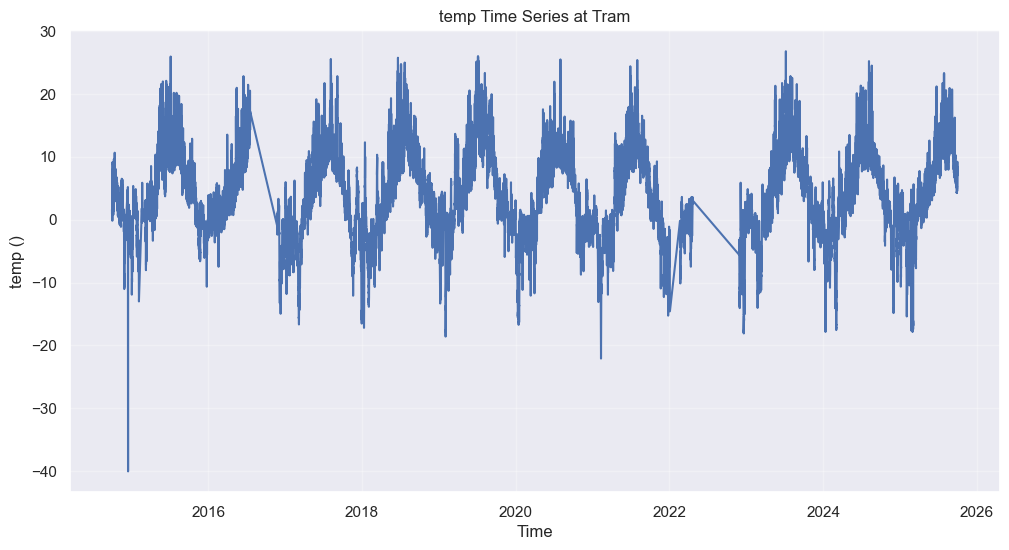

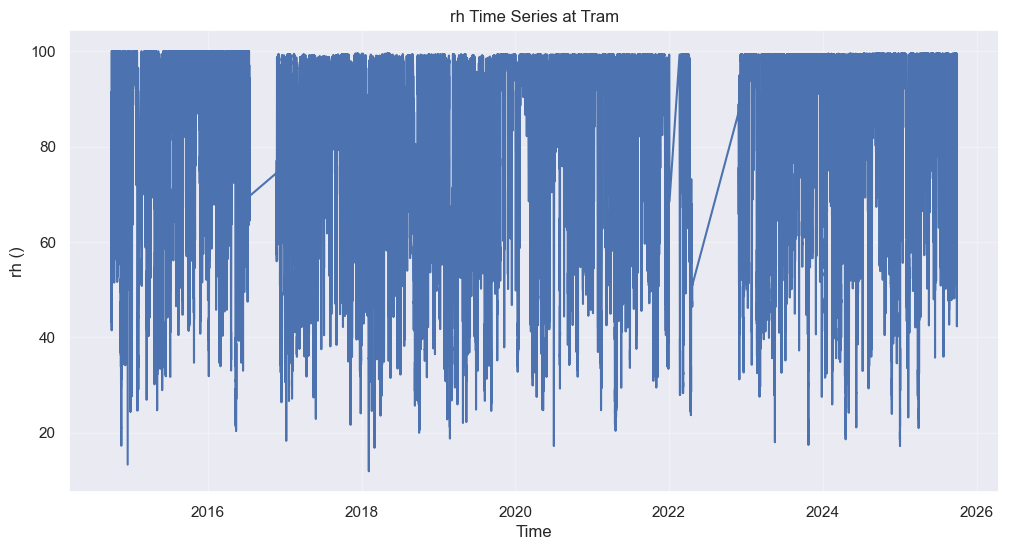

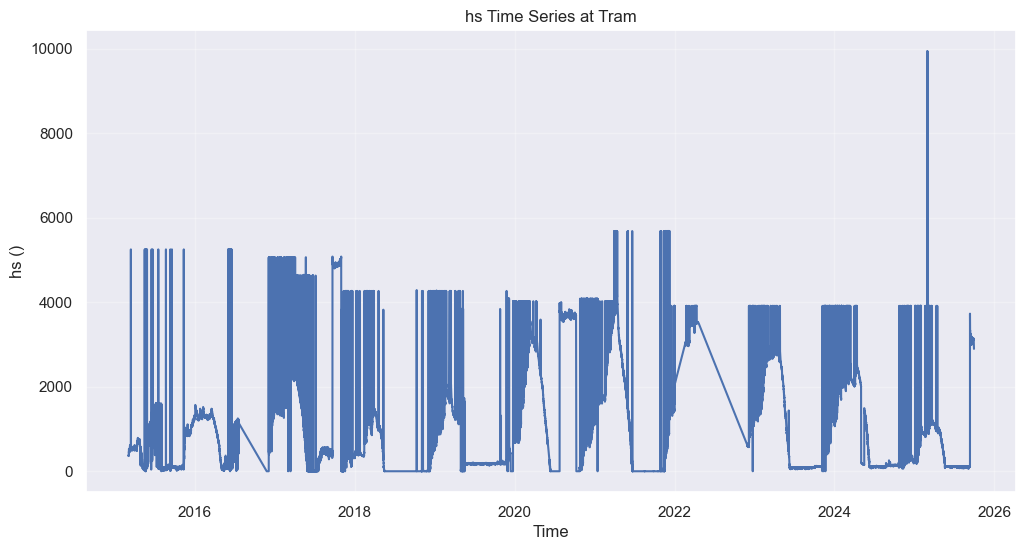

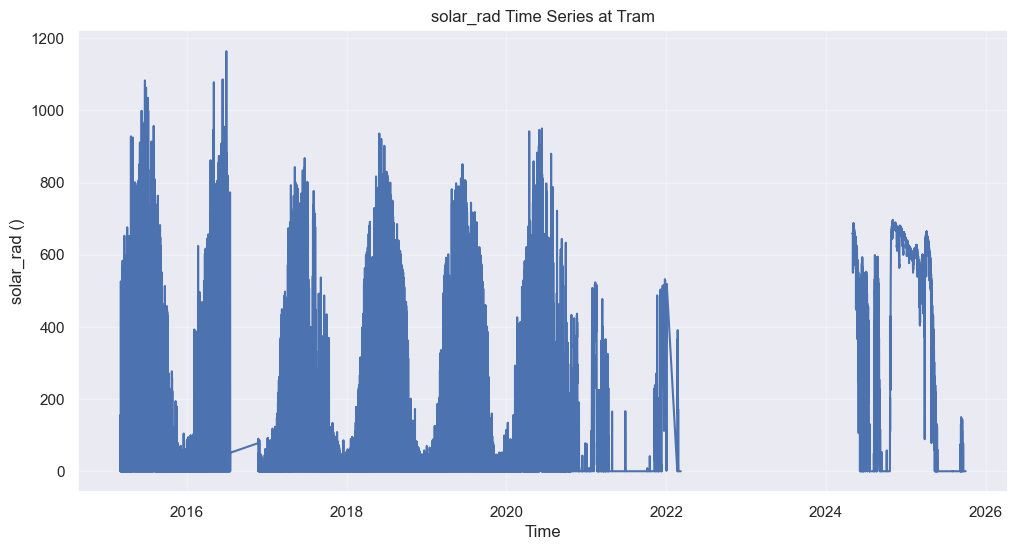

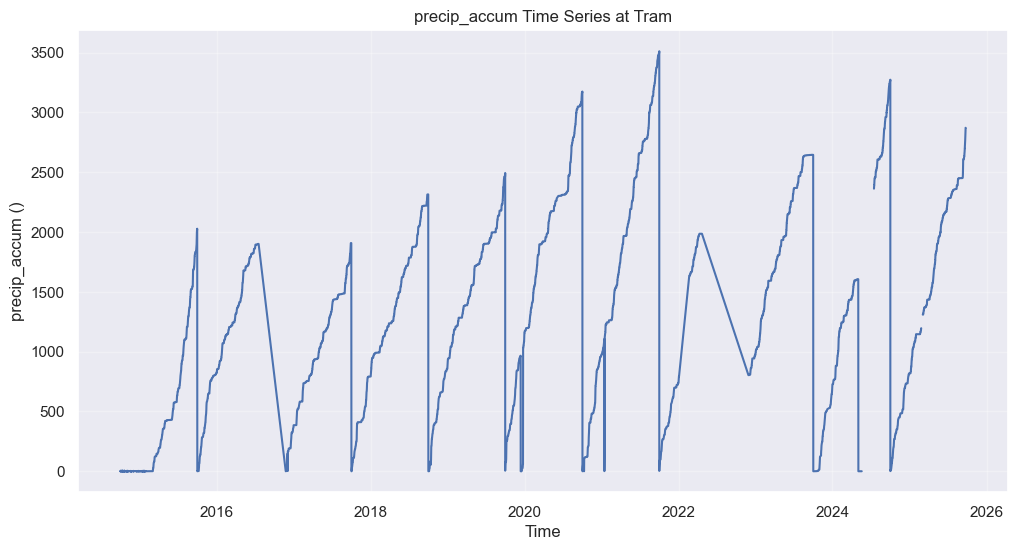

In [5]:
# Comment this out unless we want to look at it again, since we will be cutting and saving a cleaned version of the data
# plot all the variables to see what we have and how they look
for var in ds_met.data_vars:
    plt.figure()
    ds_met[var].plot()
    plt.title(f"{var} Time Series at Tram")
    plt.xlabel("Time")
    plt.ylabel(f"{var} ({ds_met[var].attrs.get('units', '')})")
    plt.grid(True, alpha=0.3)
    plt.show()
    

# Data Cleaning

In [6]:
ds_met

<xarray.Dataset> Size: 4MB
Dimensions:       (time: 92896)
Coordinates:
  * time          (time) datetime64[ns] 743kB 2014-10-01T05:00:00 ... 2025-09...
Data variables:
    temp          (time) float64 743kB 1.62 1.57 1.49 1.41 ... 6.68 4.92 4.61
    rh            (time) float64 743kB 100.0 99.8 99.1 98.1 ... 75.72 98.8 99.4
    hs            (time) float64 743kB nan nan nan ... 2.896e+03 2.896e+03
    solar_rad     (time) float64 743kB nan nan nan nan nan ... 0.0 0.0 0.0 0.0
    precip_accum  (time) float64 743kB 0.0 0.0 0.0 0.0 0.0 ... nan nan nan nan

In [7]:
# convert units 
ds_met['hs'] = ds_met['hs']*0.1 # convert mm to cm 

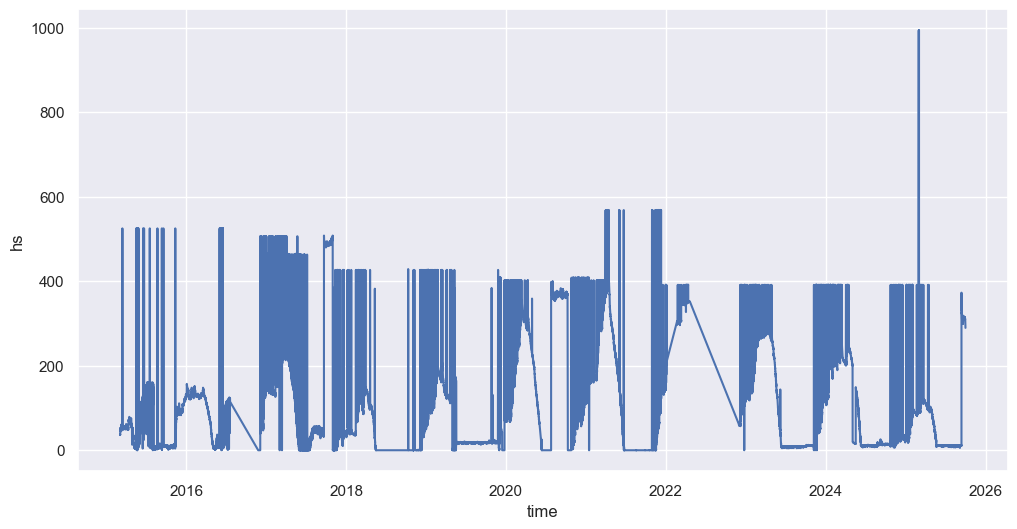

In [8]:
ds_met['hs'].plot()

In [9]:
# cleaning qc code (I've never used before)
def qc_range(da, vmin, vmax):
    return da.where((da >= vmin) & (da <= vmax))

ds_met['precip_accum'] = qc_range(ds_met['precip_accum'], 0, 40000) # in mm already 
ds_met['rh'] = qc_range(ds_met['rh'], 0, 100) # in percent 
ds_met['hs'] = qc_range(ds_met['hs'], 0, 380) # in mm, converted to cm above 
ds_met['temp'] = qc_range(ds_met['temp'], -30, 40) # in C already 


# save attributes 
ds_met["temp"].attrs['units'] = 'C'
ds_met["rh"].attrs['units'] = 'percent'
ds_met['precip_accum'].attrs['units'] = 'mm'
ds_met['hs'].attrs['units'] = 'cm'

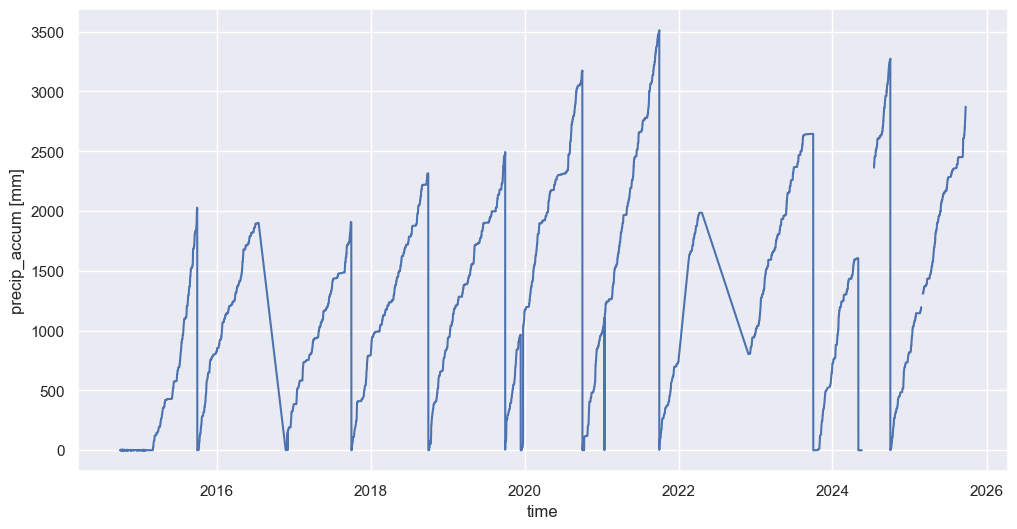

In [10]:
ds_met['precip_accum'].plot()

### Deal with duplicate timestamps (for now, keep the first occurance)

In [11]:
# # Create continuous hourly time axis
# ds_met_hourly = (ds_met.resample(time='1h').asfreq())

Deal with the duplicate timestamps, 

In [12]:
duplicate_mask = ds_met.indexes['time'].duplicated()

print(f"Number of duplicate timestamps: {duplicate_mask.sum()}")

Number of duplicate timestamps: 11


Keep the first one, 

In [13]:
ds_met = ds_met.isel(
    time=~ds_met.indexes['time'].duplicated()
)

In [14]:
print(ds_met.indexes['time'].duplicated().sum())

0


In [15]:
# PRECIP
# now we need to deal with precip
# we have total accumulated precip but we need precip per timestep for SNOWPACK 
# so first, calculate precip_rate from precip_accum (hourly timestep)
ds_met["precip_rate"] = ds_met["precip_accum"].diff("time") / 3600.0 # convert from mm/hr to mm/s for SNOWPACK
# and it can never be negative, so set any negative values to 0
ds_met["precip_rate"] = ds_met["precip_rate"].where(ds_met["precip_rate"] >= 0, 0)

# and if it is greater than 100 then set to nan
ds_met["precip_rate"] = ds_met["precip_rate"].where(ds_met["precip_rate"] < 0.03, np.nan)

# now calculate precip_accum_1hr for comparison with the HRRRAK precip variable (which is in mm/s but we can convert to mm/hr)
ds_met["precip_accum_1hr"] = ds_met["precip_rate"] * 3600 # convert from mm/s to mm/hr for comparison with the observed data

# and if it is greater than 100 then set to nan
ds_met["precip_accum_1hr"] = ds_met["precip_accum_1hr"].where(ds_met["precip_accum_1hr"] < 40, np.nan)

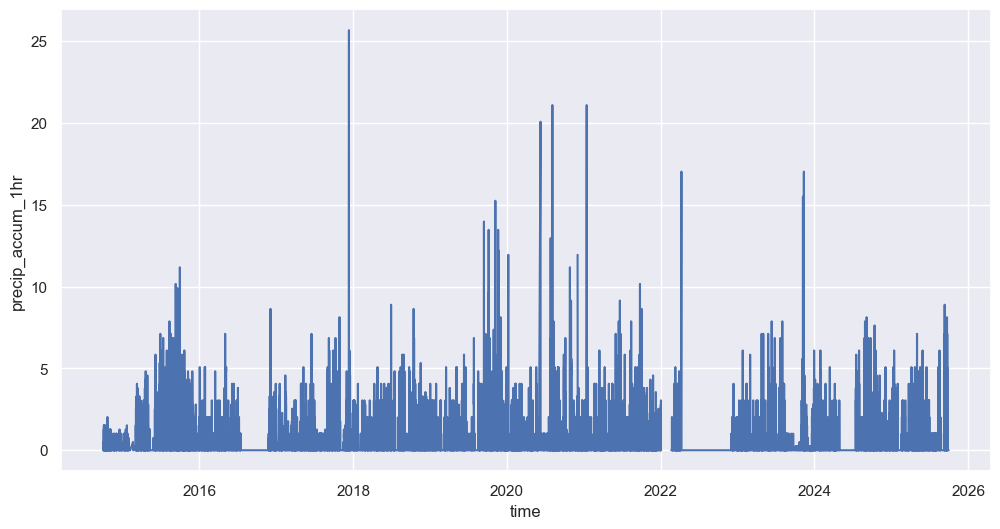

In [16]:
# ds_met['precip_rate'].plot()
ds_met['precip_accum_1hr'].plot()

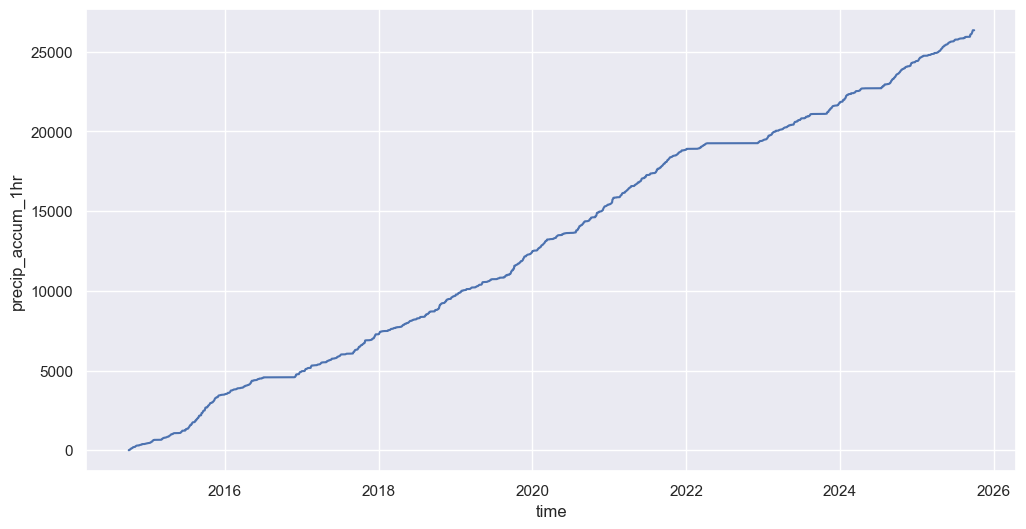

In [17]:
# ds_met['precip_accum'] = ds_met['precip_accum_1hr'].cumsum()
ds_met['precip_accum_1hr'].cumsum().plot()

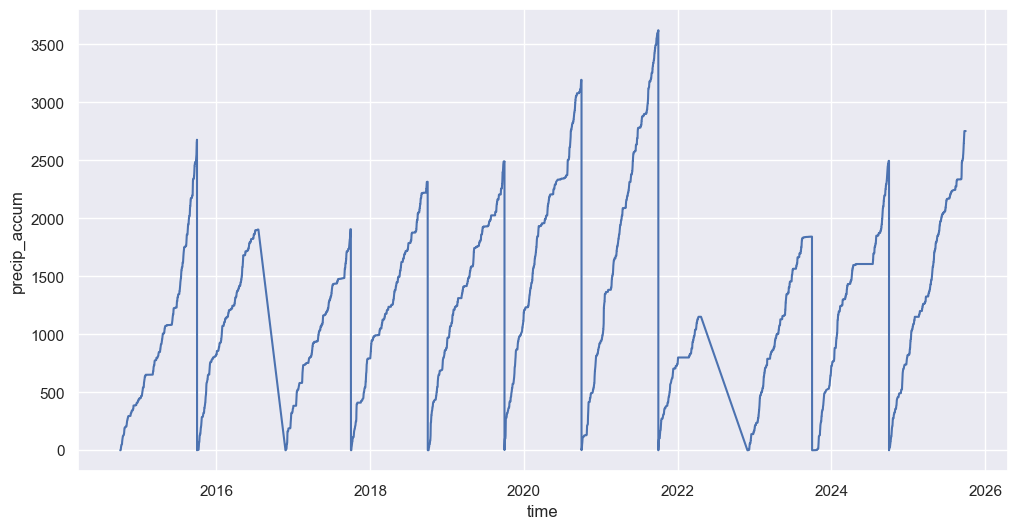

In [18]:
# Define water year
water_year = xr.where(
    ds_met.time.dt.month >= 10,
    ds_met.time.dt.year + 1,
    ds_met.time.dt.year
)

# Accumulated precipitation that resets every Oct 1
ds_met['precip_accum'] = (
    ds_met['precip_accum_1hr']
    .groupby(water_year)
    .cumsum(dim='time')
)

ds_met['precip_accum'].plot()

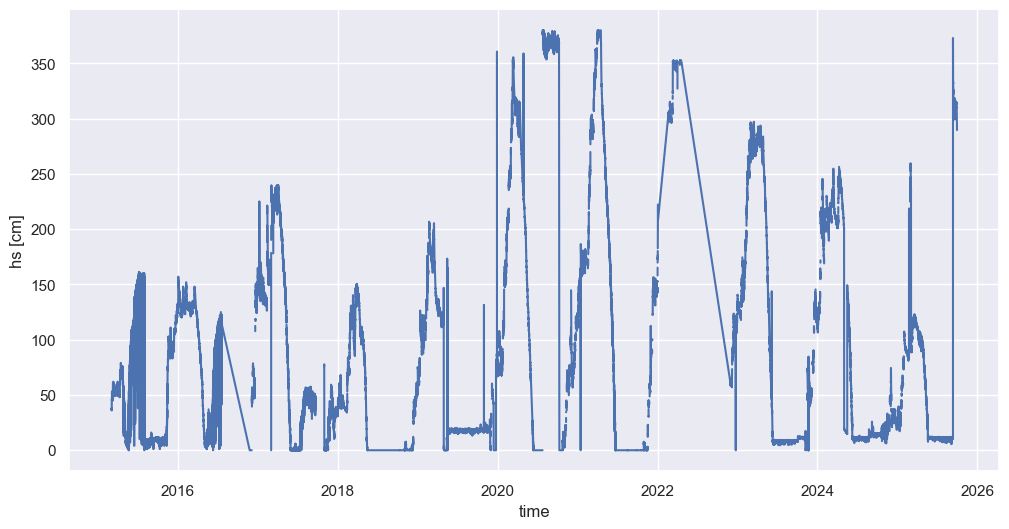

In [19]:
ds_met.hs.plot()

## Cleaning Snow Depth

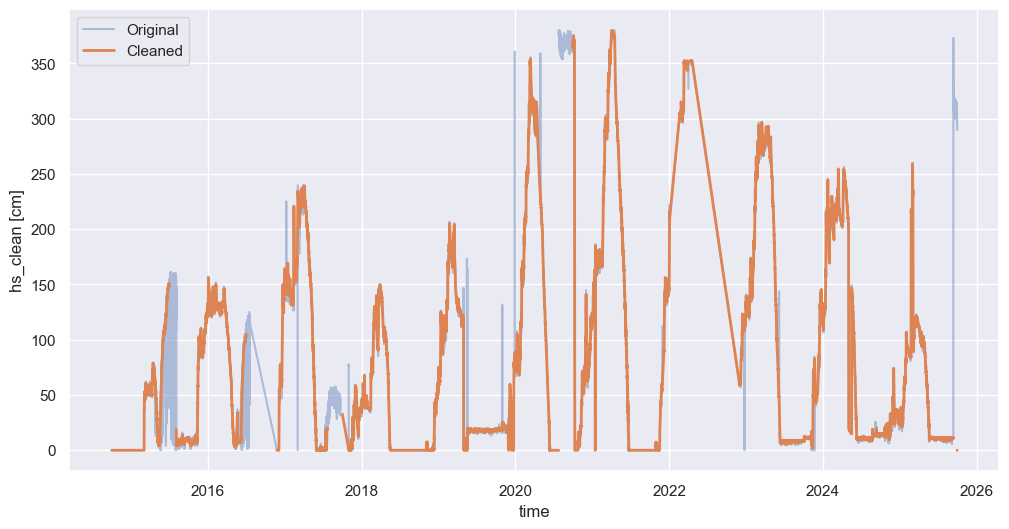

In [20]:
# -----------------------------------------------------------------------------
# CLEAN SNOW DEPTH (hs)
# -----------------------------------------------------------------------------

hs = ds_met['hs'].copy()

# Calculate timestep changes
dhs = hs.diff(dim='time')

# -----------------------------------------------------------------------------
# Define physically unrealistic changes
# -----------------------------------------------------------------------------

max_increase = 15.0   # cm per timestep
max_decrease = -20.0 # cm per timestep

bad_change = (
    (dhs > max_increase) |
    (dhs < max_decrease)
)

# Align dimensions
bad_change = xr.concat(
    [
        xr.DataArray(
            [False],
            coords={'time': [hs.time.values[0]]},
            dims='time'
        ),
        bad_change
    ],
    dim='time'
)

# -----------------------------------------------------------------------------
# Mask bad spikes
# -----------------------------------------------------------------------------

hs_clean = hs.where(~bad_change)

# -----------------------------------------------------------------------------
# Rolling median filter
# centered 5-point window
# -----------------------------------------------------------------------------

hs_clean = (
    hs_clean
    .rolling(time=5, center=True)
    .median()
)

# -----------------------------------------------------------------------------
# Fill gaps after filtering
# -----------------------------------------------------------------------------

hs_clean = hs_clean.interpolate_na(
    dim='time',
    method='linear'
)

# -----------------------------------------------------------------------------
# Remove tiny negatives
# -----------------------------------------------------------------------------

hs_clean = hs_clean.where(hs_clean >= 0, 0)

# -----------------------------------------------------------------------------
# Save
# -----------------------------------------------------------------------------

ds_met['hs_clean'] = hs_clean

# finally remove the bad summer snow 

# Set snow depth >20 cm in July/August to NaN

bad_summer_snow = (
    (ds_met.time.dt.month.isin([7, 8, 9])) &
    (ds_met['hs_clean'] > 20)
)

ds_met['hs_clean'] = ds_met['hs_clean'].where(~bad_summer_snow)

# plot the two to compare 
plt.figure()
ds_met['hs'].plot(label='Original', alpha=0.4)
ds_met['hs_clean'].plot(label='Cleaned', linewidth=2)
plt.legend()

In [21]:
# for hs the hs_final so replace that 
ds_met['hs'] = ds_met['hs_clean']
ds_met = ds_met.drop_vars('hs_clean')
ds_met

<xarray.Dataset> Size: 6MB
Dimensions:           (time: 92885)
Coordinates:
  * time              (time) datetime64[ns] 743kB 2014-10-01T05:00:00 ... 202...
Data variables:
    temp              (time) float64 743kB 1.62 1.57 1.49 ... 6.68 4.92 4.61
    rh                (time) float64 743kB 100.0 99.8 99.1 ... 75.72 98.8 99.4
    hs                (time) float64 743kB 0.0 0.0 0.0 0.0 ... nan nan 0.0 0.0
    solar_rad         (time) float64 743kB nan nan nan nan ... 0.0 0.0 0.0 0.0
    precip_accum      (time) float64 743kB 0.0 0.0 0.0 ... 2.753e+03 2.753e+03
    precip_rate       (time) float64 743kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    precip_accum_1hr  (time) float64 743kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

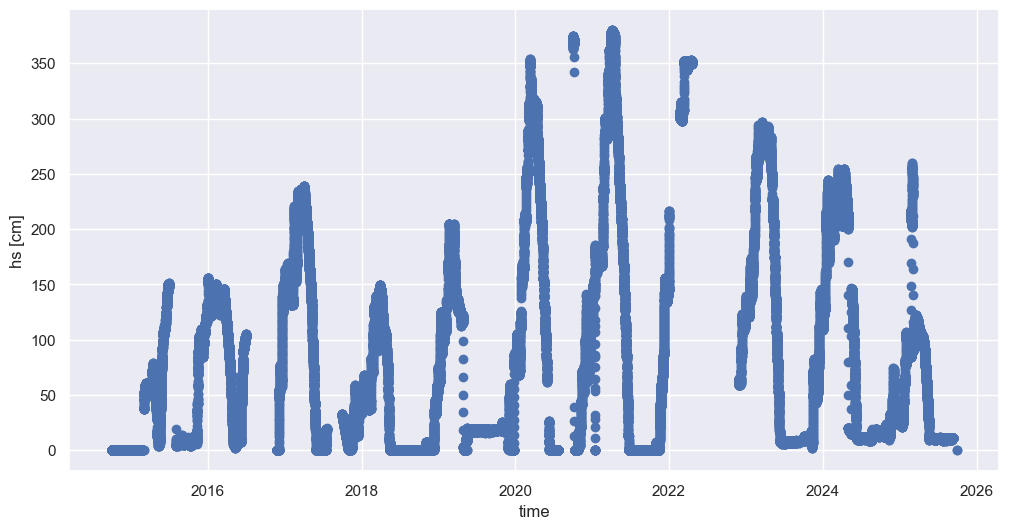

In [22]:
ds_met['hs'].plot(marker='o', linestyle='')

# Save to a new netcdf file, 

In [24]:
# save the first version of the cleaned data 
file = "/hdd/snow_hydrology/met_station/tram/tram_met_station_data_synoptic_2026-03-20"  # should really replace this with the WY2026 data once I fix that...
ds_met.to_netcdf(file)